In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
#load dataset
df=pd.read_csv('/content/TShirt_size.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Height (in cms)  18 non-null     int64 
 1   Weight (in kgs)  18 non-null     int64 
 2   T Shirt Size     18 non-null     object
dtypes: int64(2), object(1)
memory usage: 564.0+ bytes


In [4]:
df.describe()

,Height (in cms),Weight (in kgs)
count,18.00000,18.000000
mean,164.00000,62.333333
std,4.32503,2.634611
min,158.00000,58.000000
25%,160.00000,60.250000
50%,164.00000,62.500000
75%,168.00000,64.000000
max,170.00000,68.000000


In [5]:
df.shape

(18, 3)

In [6]:
print("No of Duplicated Records:",df.duplicated().sum())

No of Duplicated Records: 0


In [7]:
df.isnull().sum()

,0
Height (in cms),0
Weight (in kgs),0
T Shirt Size,0


<Axes: ylabel='Weight (in kgs)'>

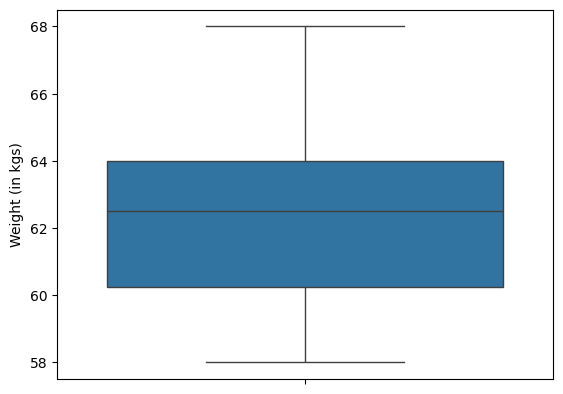

In [12]:
#identify outliers
sns.boxplot(df['Weight (in kgs)'])

<Axes: ylabel='Height (in cms)'>

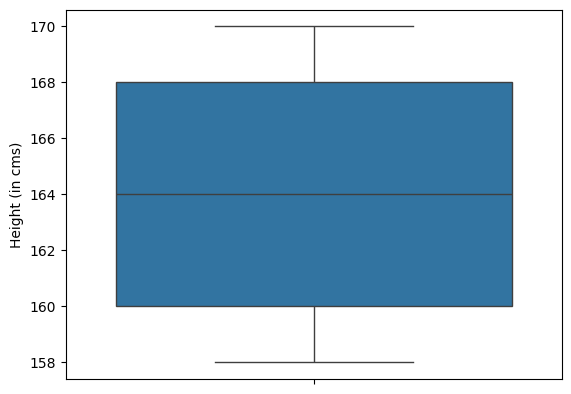

In [13]:
#identify outliers
sns.boxplot(df['Height (in cms)'])

In [15]:
#label encoding for target
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['T Shirt Size']=le.fit_transform(df['T Shirt Size'])
df.head()

,Height (in cms),Weight (in kgs),T Shirt Size
0,158,58,1
1,158,59,1
2,158,63,1
3,160,59,1
4,160,60,1


In [16]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [17]:
#split the data into training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=15)

In [18]:
#Standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [19]:
#model building
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [20]:
#predictions on test data
y_pred=knn.predict(x_test)

In [21]:
#evaluation metrics
accuracy_score(y_test,y_pred)
classification_report(y_test,y_pred)
confusion_matrix(y_test,y_pred)

array([[1, 0],
       [1, 2]])

<Axes: >

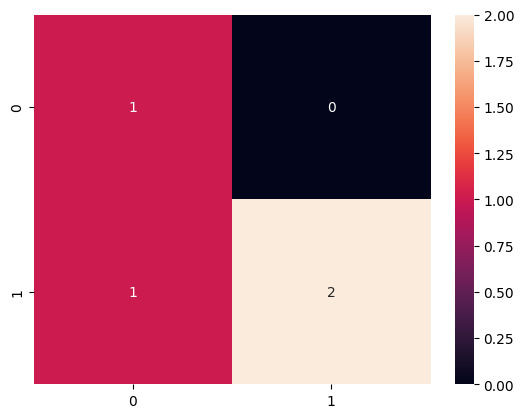

In [22]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred = knn.predict(x_test)
y_proba = knn.predict_proba(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.75
ROC-AUC Score: 1.0


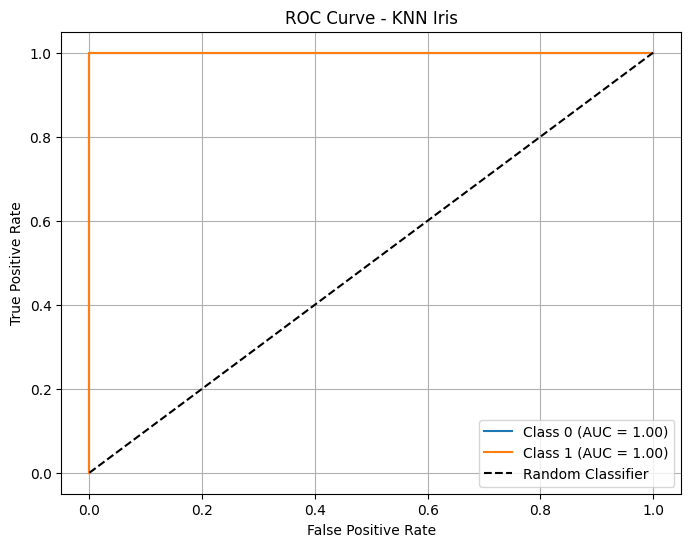

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Predict probabilities
y_proba = knn.predict_proba(x_test)
# Determine the number of classes from the test data
num_classes = len(np.unique(y_test))
# Convert test labels into binary form based on actual classes
# Using pd.get_dummies for more robust one-hot encoding
y_test_bin = pd.get_dummies(y_test).values

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(num_classes):
  # Ensure we only iterate over the actual number of classes present in y_test
  fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
  auc_score = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
  plt.plot(
    fpr, tpr,
    label=f'Class {np.unique(y_test)[i]} (AUC = {auc_score:.2f})'
  )
# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Iris')
plt.legend()
plt.grid()
plt.show()

In [29]:
overall_auc = roc_auc_score(
y_test_bin,

y_proba,
multi_class='ovr'
)
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 1.0
